In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.offline as py
import plotly.graph_objs as go
import plotly.tools as  tls
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
ccf_df=pd.read_csv('creditcard.csv')

In [3]:
ccf_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
ccf_df.shape

(284807, 31)

In [5]:
ccf_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
ccf_df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [7]:
ccf_df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
dups=ccf_df.duplicated()
ccf_df[dups]

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282987,171288.0,1.912550,-0.455240,-1.750654,0.454324,2.089130,4.160019,-0.881302,1.081750,1.022928,...,-0.524067,-1.337510,0.473943,0.616683,-0.283548,-1.084843,0.073133,-0.036020,11.99,0
283483,171627.0,-1.464380,1.368119,0.815992,-0.601282,-0.689115,-0.487154,-0.303778,0.884953,0.054065,...,0.287217,0.947825,-0.218773,0.082926,0.044127,0.639270,0.213565,0.119251,6.82,0
283485,171627.0,-1.457978,1.378203,0.811515,-0.603760,-0.711883,-0.471672,-0.282535,0.880654,0.052808,...,0.284205,0.949659,-0.216949,0.083250,0.044944,0.639933,0.219432,0.116772,11.93,0
284191,172233.0,-2.667936,3.160505,-3.355984,1.007845,-0.377397,-0.109730,-0.667233,2.309700,-1.639306,...,0.391483,0.266536,-0.079853,-0.096395,0.086719,-0.451128,-1.183743,-0.222200,55.66,0


In [9]:
ccf_df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [10]:
ccf_df['Time'] = ccf_df['Time'].astype(int)

In [11]:
ccf_df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


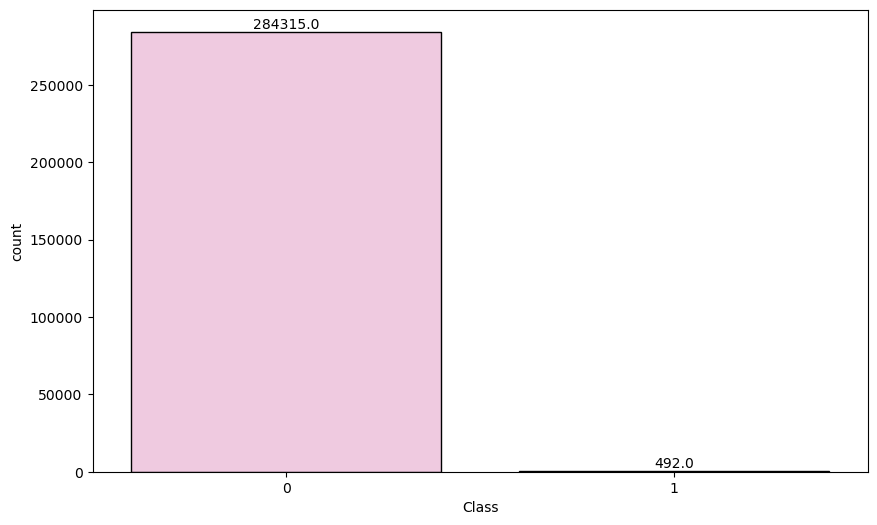

In [12]:
plt.figure(figsize=(10,6))
ax=sns.countplot(data=ccf_df,x='Class',palette='PiYG', edgecolor='black')
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.show()

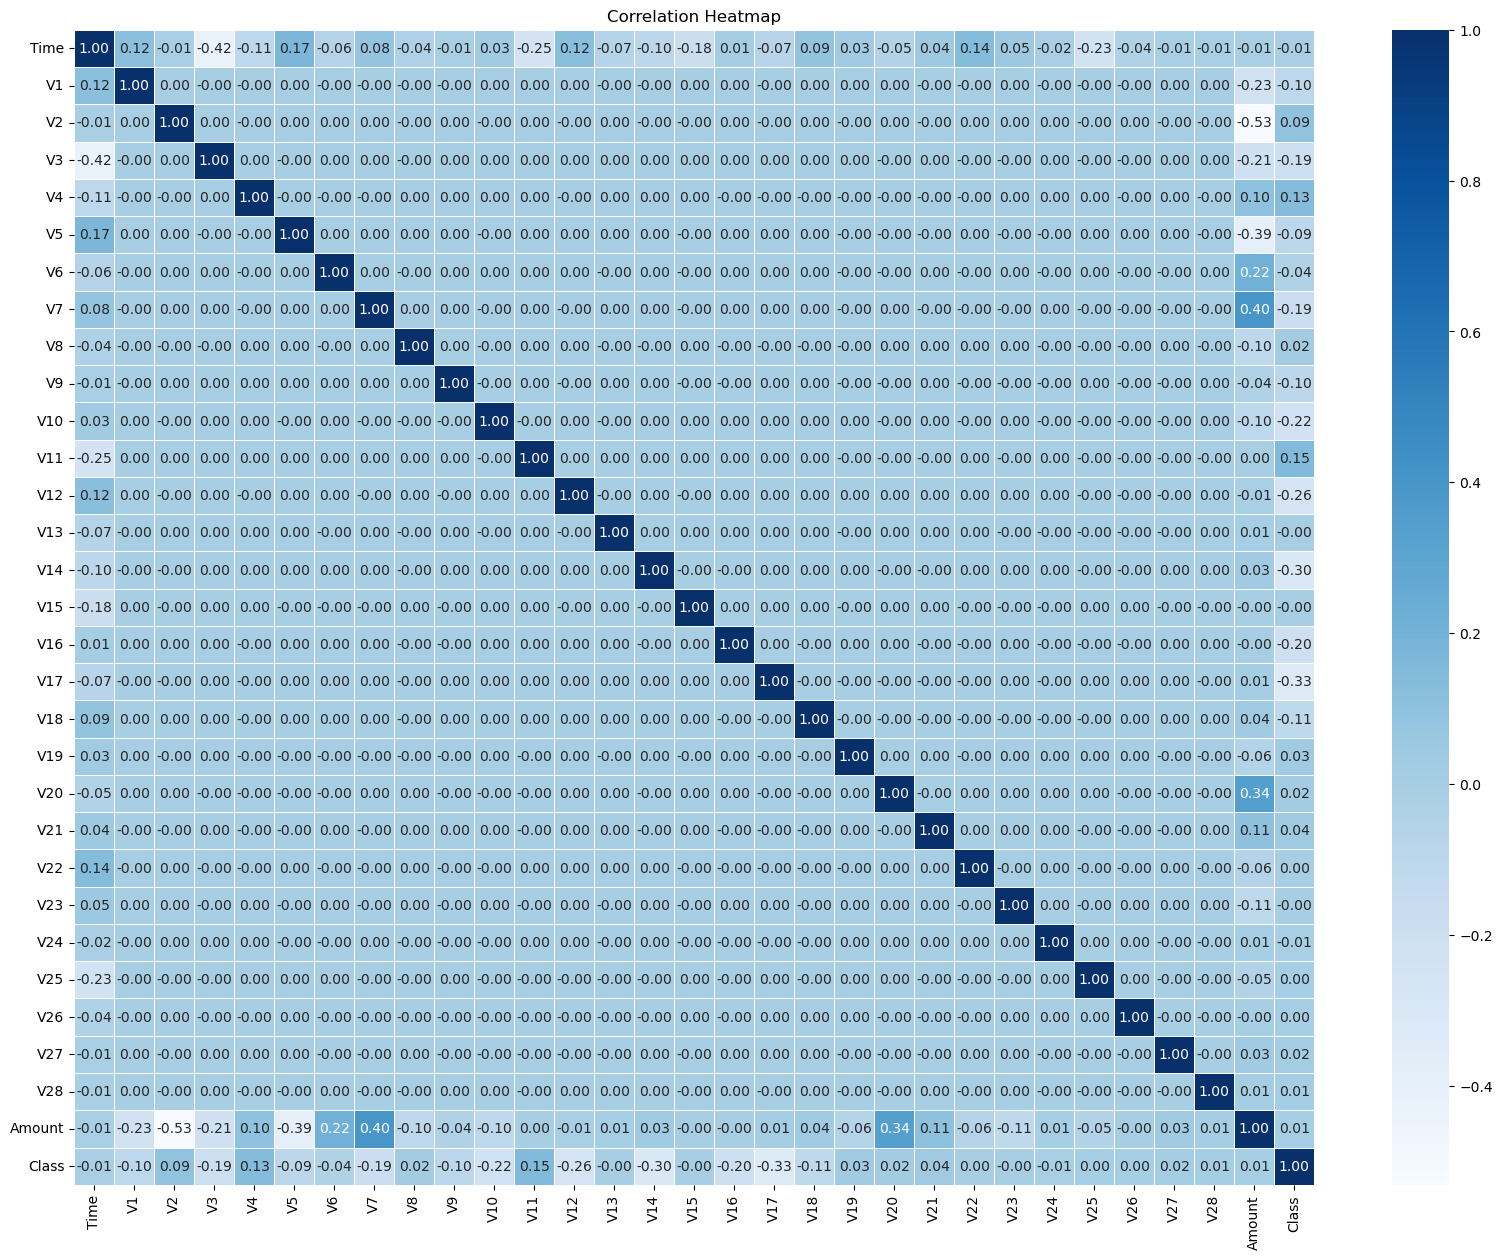

In [13]:
plt.figure(figsize=(20,15))

sns.heatmap(ccf_df.corr(numeric_only=True),
            annot=True,
            cmap='Blues',
            fmt='.2f',
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

array([[<Axes: title={'center': 'Time'}>, <Axes: title={'center': 'V1'}>,
        <Axes: title={'center': 'V2'}>, <Axes: title={'center': 'V3'}>,
        <Axes: title={'center': 'V4'}>, <Axes: title={'center': 'V5'}>],
       [<Axes: title={'center': 'V6'}>, <Axes: title={'center': 'V7'}>,
        <Axes: title={'center': 'V8'}>, <Axes: title={'center': 'V9'}>,
        <Axes: title={'center': 'V10'}>, <Axes: title={'center': 'V11'}>],
       [<Axes: title={'center': 'V12'}>, <Axes: title={'center': 'V13'}>,
        <Axes: title={'center': 'V14'}>, <Axes: title={'center': 'V15'}>,
        <Axes: title={'center': 'V16'}>, <Axes: title={'center': 'V17'}>],
       [<Axes: title={'center': 'V18'}>, <Axes: title={'center': 'V19'}>,
        <Axes: title={'center': 'V20'}>, <Axes: title={'center': 'V21'}>,
        <Axes: title={'center': 'V22'}>, <Axes: title={'center': 'V23'}>],
       [<Axes: title={'center': 'V24'}>, <Axes: title={'center': 'V25'}>,
        <Axes: title={'center': 'V26'}>, <

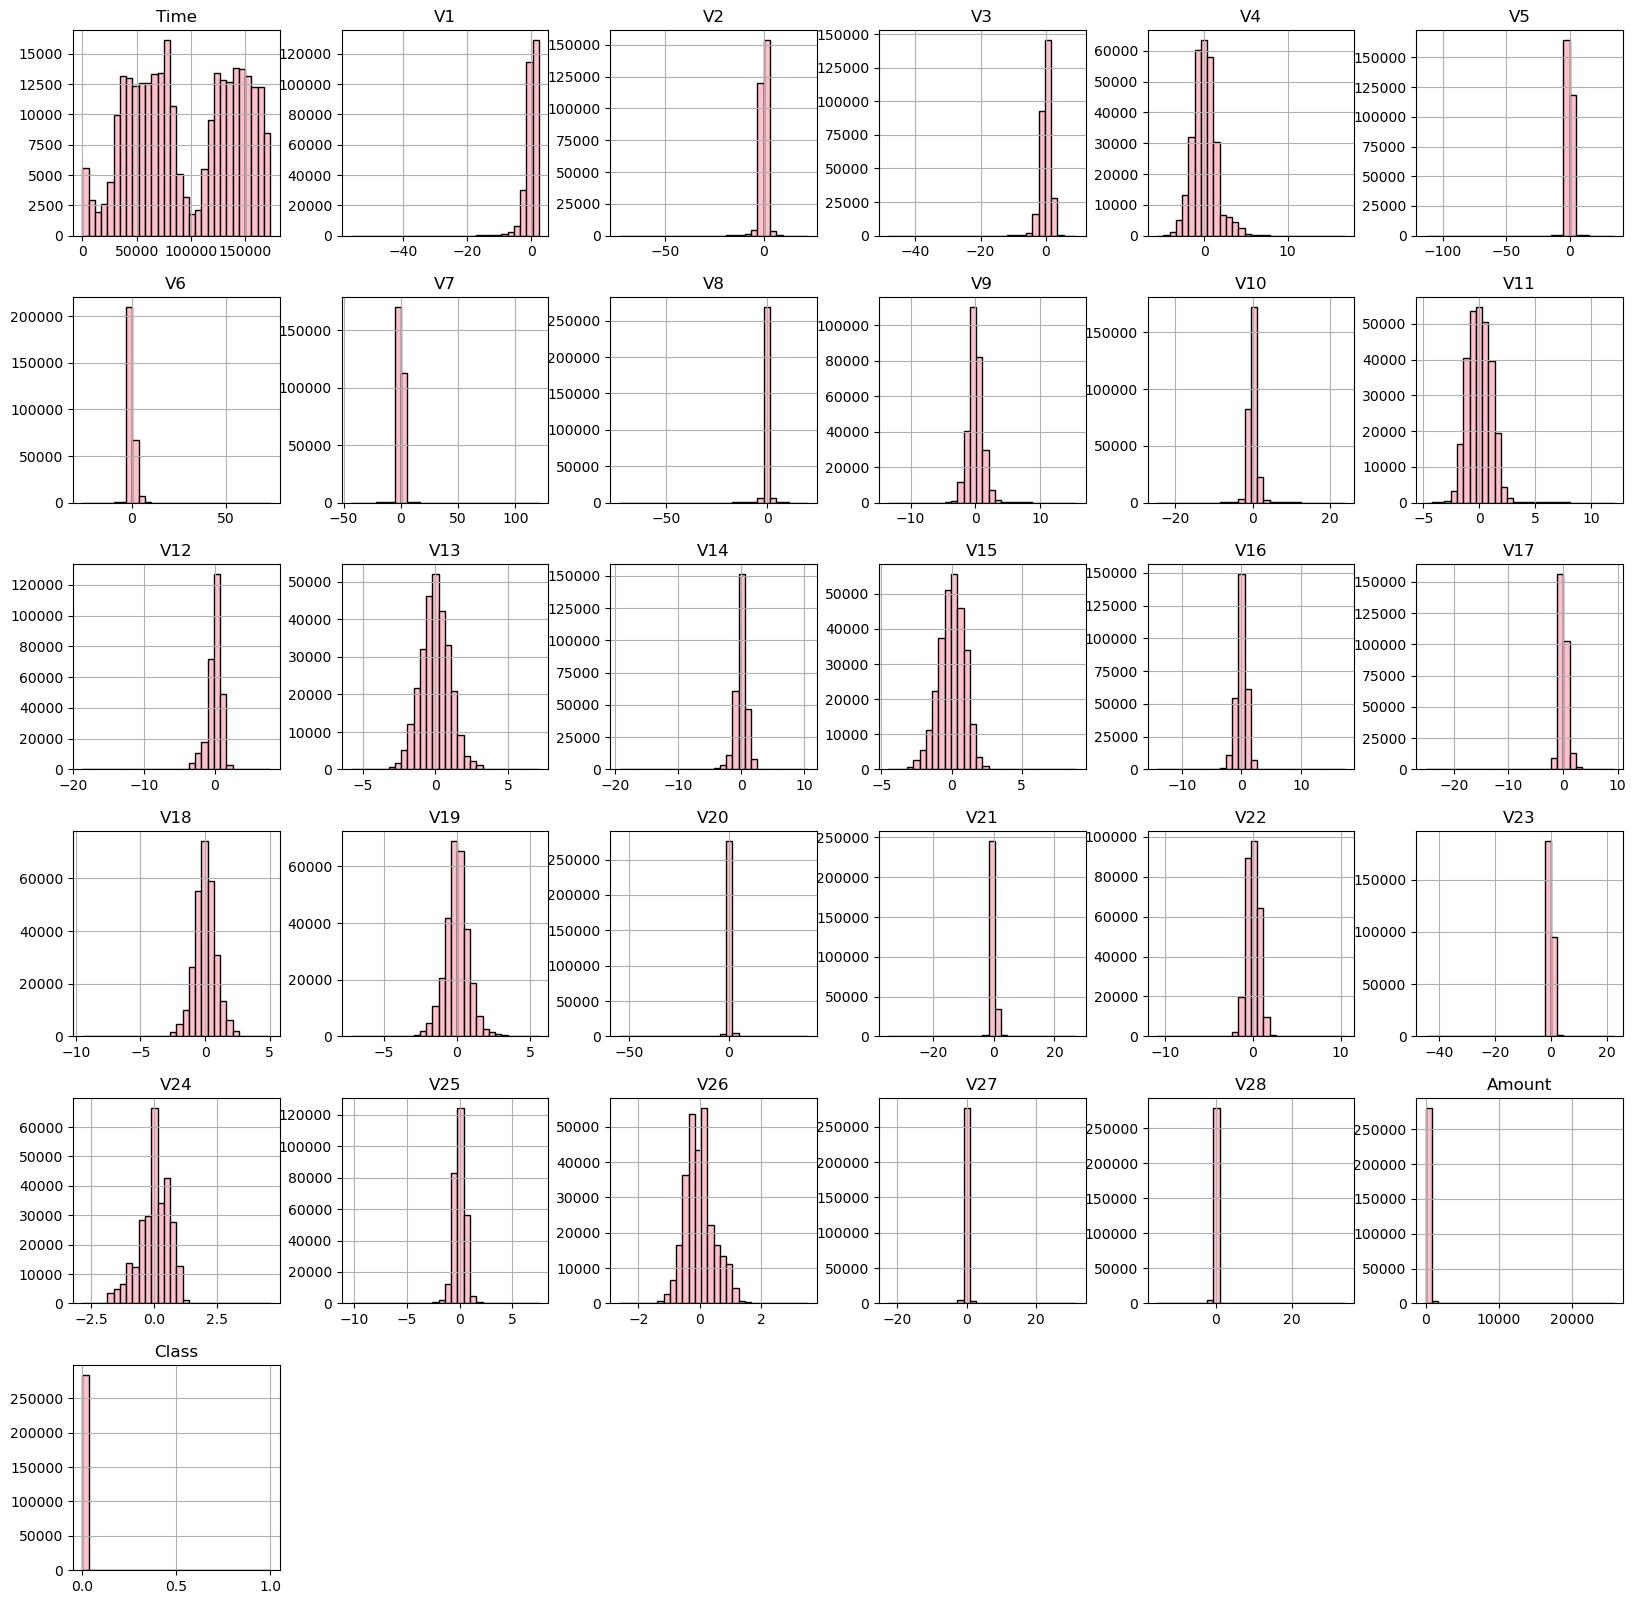

In [14]:
ccf_df.hist(figsize=(20, 20), bins=30, color='pink',edgecolor='black',linewidth=1)

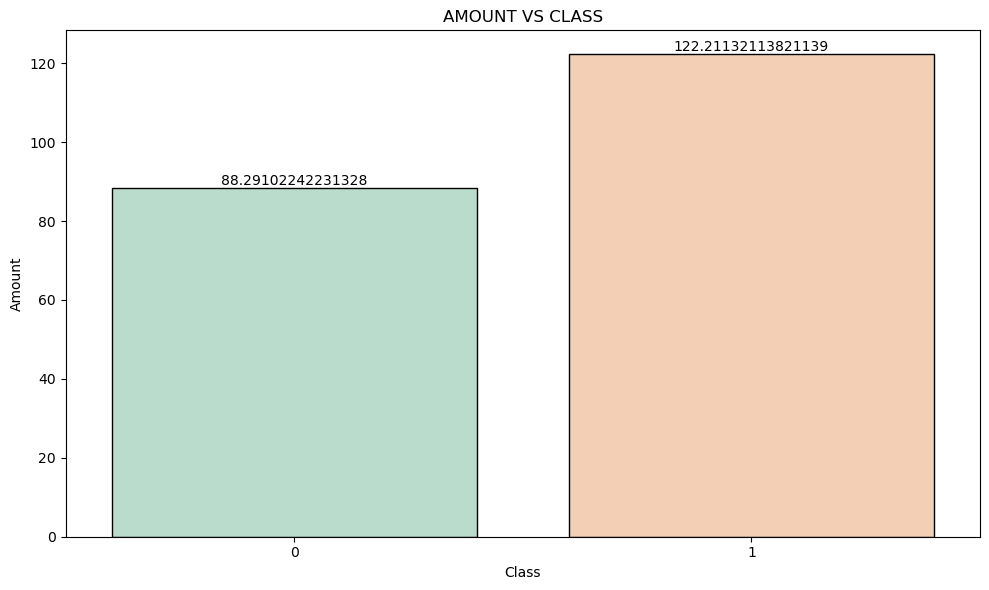

In [15]:
plt.figure(figsize=(10,6))
ax=sns.barplot(data=ccf_df,x='Class',y='Amount',palette='Pastel2',ci=None,edgecolor='black')
for p in ax.patches:
    ax.annotate(
        format((p.get_height())),
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom'
    )
plt.title("AMOUNT VS CLASS")
plt.tight_layout()
plt.show()

In [16]:
ccf_df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

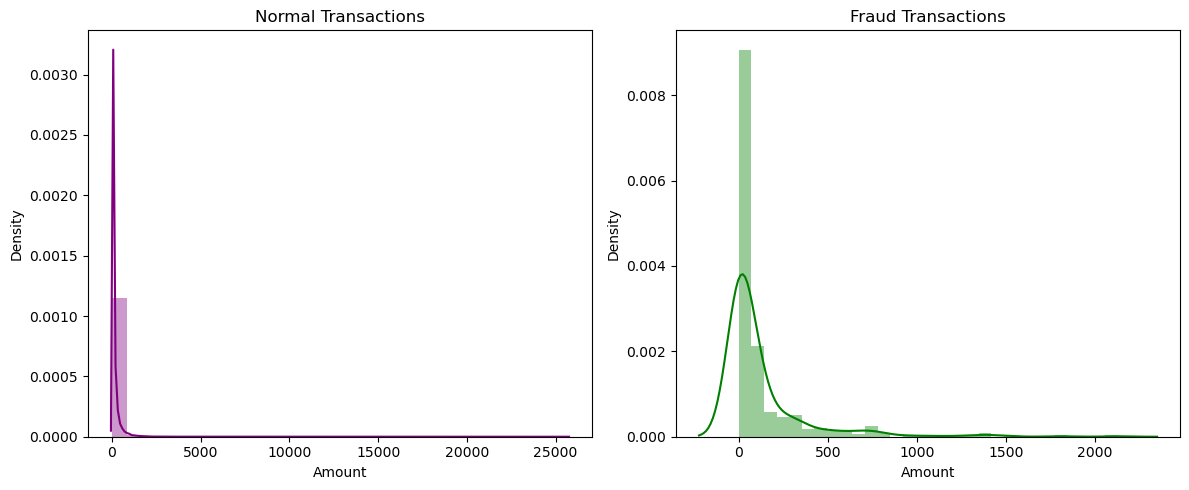

In [17]:
normal = ccf_df[ccf_df['Class'] == 0]
fraud = ccf_df[ccf_df['Class'] == 1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.distplot(normal['Amount'], kde=True, bins=30, color='purple')
plt.title('Normal Transactions')

plt.subplot(1, 2, 2)
sns.distplot(fraud['Amount'], kde=True, bins=30, color='green')
plt.title('Fraud Transactions')

plt.tight_layout()
plt.show()


    

In [18]:
ccf_df["LogAmount"] = np.log1p(ccf_df["Amount"])

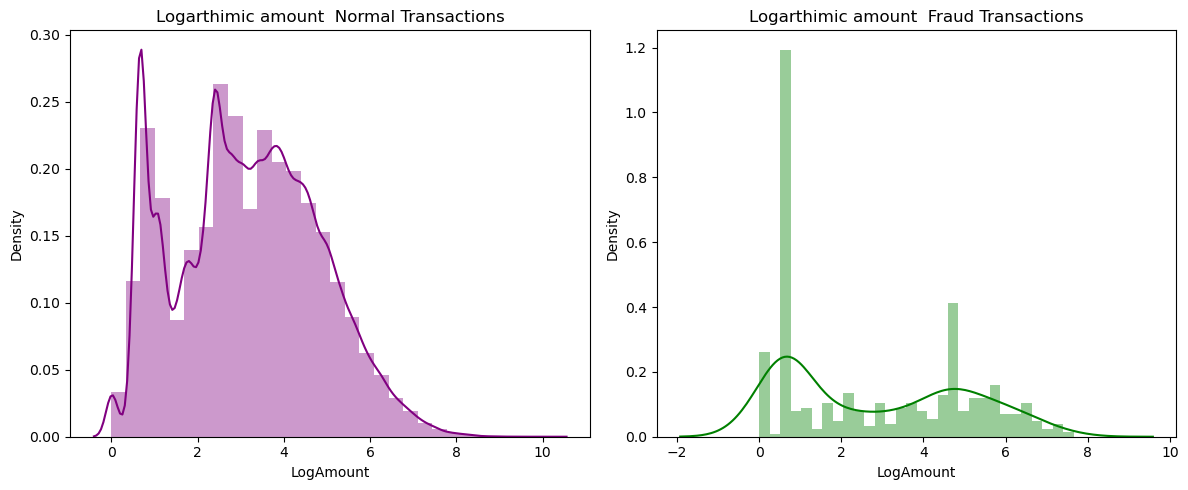

In [19]:
normal = ccf_df[ccf_df['Class'] == 0]
fraud = ccf_df[ccf_df['Class'] == 1]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.distplot(normal['LogAmount'], kde=True, bins=30, color='purple')
plt.title('Logarthimic amount  Normal Transactions')

plt.subplot(1, 2, 2)
sns.distplot(fraud['LogAmount'], kde=True, bins=30, color='green')
plt.title('Logarthimic amount  Fraud Transactions')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'disturbution of time over the transactions')

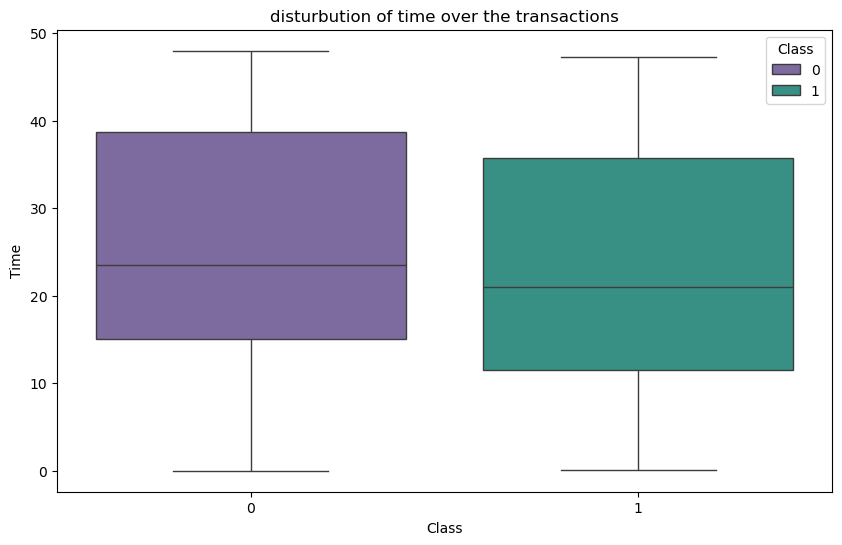

In [20]:
normal = ccf_df[ccf_df['Class'] == 0]
fraud = ccf_df[ccf_df['Class'] == 1]
ccf_df['Time']=ccf_df['Time']/3600
plt.figure(figsize=(10,6))
sns.boxplot(data=ccf_df,x='Class',y='Time',hue='Class',palette=['#7B61A8',  '#2A9D8F'])
plt.title('disturbution of time over the transactions')


In [21]:
normal = ccf_df[ccf_df['Class'] == 0]
normal.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,LogAmount
count,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,...,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.000000,284315.0,284315.000000
mean,26.343945,0.008258,-0.006271,0.012171,-0.007860,0.005453,0.002419,0.009637,-0.000987,0.004467,...,-0.000024,0.000070,0.000182,-0.000072,-0.000089,-0.000295,-0.000131,88.291022,0.0,3.152762
std,13.190004,1.929814,1.636146,1.459429,1.399333,1.356952,1.329913,1.178812,1.161283,1.089372,...,0.723668,0.621541,0.605776,0.520673,0.482241,0.399847,0.329570,250.105092,0.0,1.655468
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-31.764946,-73.216718,-6.290730,...,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.0,0.000000
25%,15.063889,-0.917544,-0.599473,-0.884541,-0.850077,-0.689398,-0.766847,-0.551442,-0.208633,-0.640412,...,-0.542403,-0.161702,-0.354425,-0.317145,-0.327074,-0.070852,-0.052950,5.650000,0.0,1.894617
50%,23.530833,0.020023,0.064070,0.182158,-0.022405,-0.053457,-0.273123,0.041138,0.022041,-0.049964,...,0.006736,-0.011147,0.041082,0.016417,-0.052227,0.001230,0.011199,22.000000,0.0,3.135494
75%,38.703611,1.316218,0.800446,1.028372,0.737624,0.612181,0.399619,0.571019,0.326200,0.598230,...,0.528407,0.147522,0.439869,0.350594,0.240671,0.090573,0.077962,77.050000,0.0,4.357350
max,47.997778,2.454930,18.902453,9.382558,16.875344,34.801666,73.301626,120.589494,18.709255,15.594995,...,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,0.0,10.153941


In [22]:
fraud = ccf_df[ccf_df['Class'] == 1]
fraud.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,LogAmount
count,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,...,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.000000,492.0,492.000000
mean,22.429669,-4.771948,3.623778,-7.033281,4.542029,-3.151225,-1.397737,-5.568731,0.570636,-2.581123,...,0.014049,-0.040308,-0.105130,0.041449,0.051648,0.170575,0.075667,122.211321,1.0,2.820596
std,13.287601,6.783687,4.291216,7.110937,2.873318,5.372468,1.858124,7.206773,6.797831,2.500896,...,1.494602,1.579642,0.515577,0.797205,0.471679,1.376766,0.547291,256.683288,0.0,2.214342
min,0.112778,-30.552380,-8.402154,-31.103685,-1.313275,-22.105532,-6.406267,-43.557242,-41.044261,-13.434066,...,-8.887017,-19.254328,-2.028024,-4.781606,-1.152671,-7.263482,-1.869290,0.000000,1.0,0.000000
25%,11.455972,-6.036063,1.188226,-8.643489,2.373050,-4.792835,-2.501511,-7.965295,-0.195336,-3.872383,...,-0.533764,-0.342175,-0.436809,-0.314348,-0.259416,-0.020025,-0.108868,1.000000,1.0,0.693147
50%,20.991250,-2.342497,2.717869,-5.075257,4.177147,-1.522962,-1.424616,-3.034402,0.621508,-2.208768,...,0.048434,-0.073135,-0.060795,0.088371,0.004321,0.394926,0.146344,9.250000,1.0,2.327270
75%,35.689722,-0.419200,4.971257,-2.276185,6.348729,0.214562,-0.413216,-0.945954,1.764879,-0.787850,...,0.617474,0.308378,0.285328,0.456515,0.396733,0.826029,0.381152,105.890000,1.0,4.671800
max,47.318889,2.132386,22.057729,2.250210,12.114672,11.095089,6.474115,5.802537,20.007208,3.353525,...,8.361985,5.466230,1.091435,2.208209,2.745261,3.052358,1.779364,2125.870000,1.0,7.662407


In [23]:
def show_fraud_normal_stat(feature: str):
    fraud_stats = ccf_df[ccf_df['Class'] == 1][feature].describe()
    normal_stats =ccf_df[ccf_df['Class'] == 0][feature].describe()
    
    stats_df = pd.concat([fraud_stats, normal_stats], axis=1)
    stats_df.columns = ['Fraud', 'Normal']
    
    print(f'\nDescriptive Statistics for "{feature}"\n')
    print(stats_df)

In [24]:
show_fraud_normal_stat('LogAmount')


Descriptive Statistics for "LogAmount"

            Fraud         Normal
count  492.000000  284315.000000
mean     2.820596       3.152762
std      2.214342       1.655468
min      0.000000       0.000000
25%      0.693147       1.894617
50%      2.327270       3.135494
75%      4.671800       4.357350
max      7.662407      10.153941


In [25]:
show_fraud_normal_stat('Amount')


Descriptive Statistics for "Amount"

             Fraud         Normal
count   492.000000  284315.000000
mean    122.211321      88.291022
std     256.683288     250.105092
min       0.000000       0.000000
25%       1.000000       5.650000
50%       9.250000      22.000000
75%     105.890000      77.050000
max    2125.870000   25691.160000


In [26]:
show_fraud_normal_stat('Time')


Descriptive Statistics for "Time"

            Fraud         Normal
count  492.000000  284315.000000
mean    22.429669      26.343945
std     13.287601      13.190004
min      0.112778       0.000000
25%     11.455972      15.063889
50%     20.991250      23.530833
75%     35.689722      38.703611
max     47.318889      47.997778


In [27]:
X = ccf_df.drop(columns="Class", axis=1)
Y = ccf_df["Class"]

In [28]:
X.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,LogAmount
0,0.000000,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,5.014760
1,0.000000,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,1.305626
2,0.000278,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,5.939276
3,0.000278,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,4.824306
4,0.000556,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,4.262539


In [29]:
Y.head()

0    0
1    0
2    0
3    0
4    0
Name: Class, dtype: int64

In [30]:
from sklearn.model_selection import train_test_split  
X_train,X_test, Y_train,Y_test = train_test_split(
    X, 
    Y, 
    test_size=0.2, 
    random_state=42 ,
    stratify = Y
)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [32]:
from imblearn.pipeline import make_pipeline as make_pipeline_imb
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import make_pipeline
from imblearn.metrics import classification_report_imbalanced
from collections import Counter

In [33]:
smote = SMOTE(random_state=42)

X_train_resampled, Y_train_resampled = smote.fit_resample(
    X_train_scaled,
    Y_train
)

In [34]:
Counter(Y_train_resampled)

Counter({0: 227451, 1: 227451})

In [35]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression
lr=LogisticRegression(max_iter=1000)

In [36]:
lr.fit(X_train_resampled,Y_train_resampled)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [37]:
y_pred = lr.predict(X_test_scaled)
print(y_pred)

[0 0 0 ... 0 0 0]


In [38]:
lr.score(X_train_resampled,Y_train_resampled)

0.9522380644622358

In [39]:
lr.score(X_test_scaled, Y_test)

0.9743688774972789

In [68]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)
print("the accuracy of lr :",accuracy_score(Y_test, y_pred))
print("the presicion of lr :",precision_score(Y_test, y_pred))
print("the recall of lr :",recall_score(Y_test, y_pred))
print("the f1_score of lr :",f1_score(Y_test, y_pred))
lr_accuracy=accuracy_score(Y_test, y_pred)
lr_precision=precision_score(Y_test, y_pred)
lr_recall=recall_score(Y_test, y_pred)
lr_f1=f1_score(Y_test, y_pred)
confusion_matrix(Y_test, y_pred)

the accuracy of lr : 0.9994908886626171
the presicion of lr : 0.8709677419354839
the recall of lr : 0.826530612244898
the f1_score of lr : 0.8481675392670157


array([[56852,    12],
       [   17,    81]])

In [41]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [42]:
cm = confusion_matrix(Y_test, y_pred)
print(cm)

[[55412  1452]
 [    8    90]]


from this modal we can understand as it has high recall and low prediction so misleading info 

In [43]:
y_prob = lr.predict_proba(X_test_scaled)[:, 1]
roc_auc_score(Y_test, y_prob)
## roc-auc tells us how well the model can distinquish between 0 and 1 across 
##differnt class


0.9713266813478345

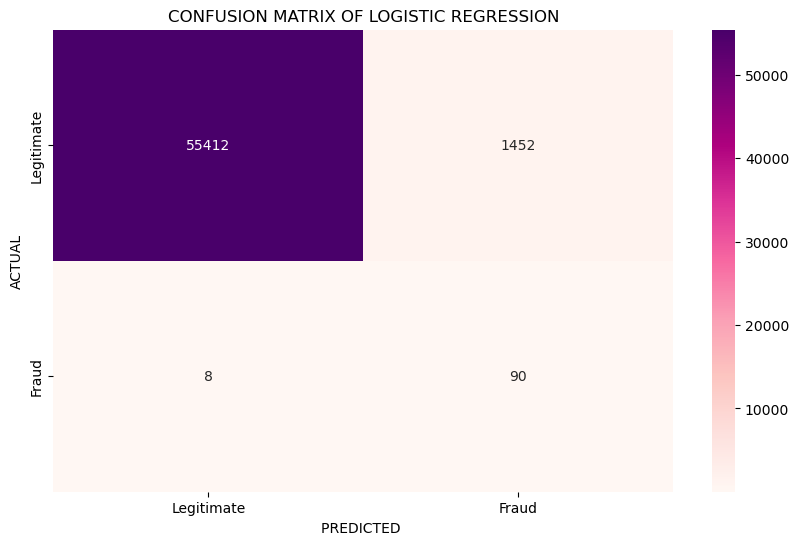

In [44]:
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='RdPu',xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud'])
plt.title('CONFUSION MATRIX OF LOGISTIC REGRESSION')
plt.xlabel('PREDICTED ')
plt.ylabel('ACTUAL')
plt.show()

In [45]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_resampled,Y_train_resampled)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [77]:
y_pred = knn.predict(X_test_scaled)
print(y_pred)

[0 0 0 ... 0 0 0]


In [78]:
print("the accuracy of knn :",accuracy_score(Y_test, y_pred))
print("the presicion of knn :",precision_score(Y_test, y_pred))
print("the recall of knn:",recall_score(Y_test, y_pred))
print("the f1_score of knn :",f1_score(Y_test, y_pred))
confusion_matrix(Y_test, y_pred)
knn_accuracy=accuracy_score(Y_test, y_pred)
knn_precision=precision_score(Y_test, y_pred)
knn_recall=recall_score(Y_test, y_pred)
knn_f1=f1_score(Y_test, y_pred)

the accuracy of knn : 0.9979986657771848
the presicion of knn : 0.4574468085106383
the recall of knn: 0.8775510204081632
the f1_score of knn : 0.6013986013986014


In [48]:
y_prob = knn.predict_proba(X_test_scaled)[:, 1]
roc_auc_score(Y_test, y_prob)

0.9484932003893286

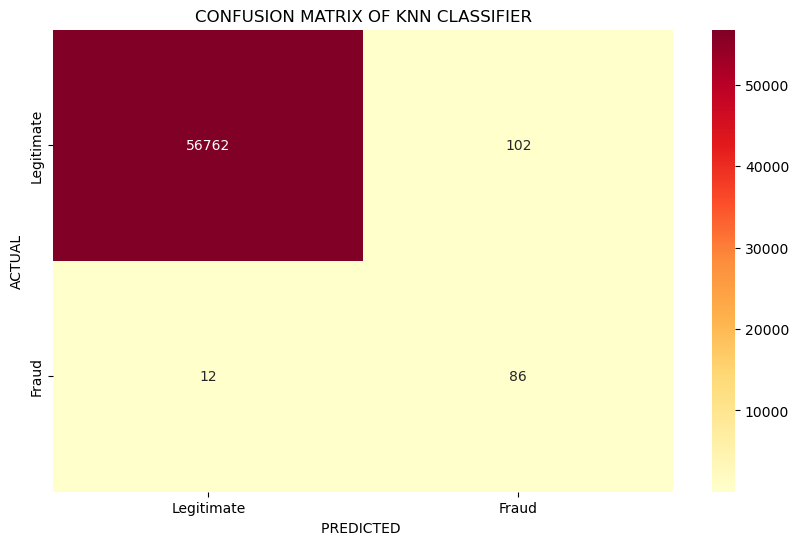

In [49]:
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='YlOrRd',xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud'])
plt.title('CONFUSION MATRIX OF KNN CLASSIFIER')
plt.xlabel('PREDICTED ')
plt.ylabel('ACTUAL')
plt.show()

In [50]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(
    random_state=42
)
dt.fit(
    X_train_resampled,
    Y_train_resampled
)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [79]:
y_pred = dt.predict(X_test_scaled)
print(y_pred)

[0 0 0 ... 0 0 0]


In [80]:
y_prob = dt.predict_proba(X_test_scaled)[:, 1]
roc_auc_score(Y_test, y_prob)

0.8968512770893388

In [81]:
print("the accuracy of dt :",accuracy_score(Y_test, y_pred))
print("the presicion of dt :",precision_score(Y_test, y_pred))
print("the recall of dt:",recall_score(Y_test, y_pred))
print("the f1_score of dt:",f1_score(Y_test, y_pred))
confusion_matrix(Y_test, y_pred)
dt_accuracy=accuracy_score(Y_test, y_pred)
dt_precision=precision_score(Y_test, y_pred)
dt_recall=recall_score(Y_test, y_pred)
dt_f1=f1_score(Y_test, y_pred)

the accuracy of dt : 0.9974368877497279
the presicion of dt : 0.38235294117647056
the recall of dt: 0.7959183673469388
the f1_score of dt: 0.5165562913907285


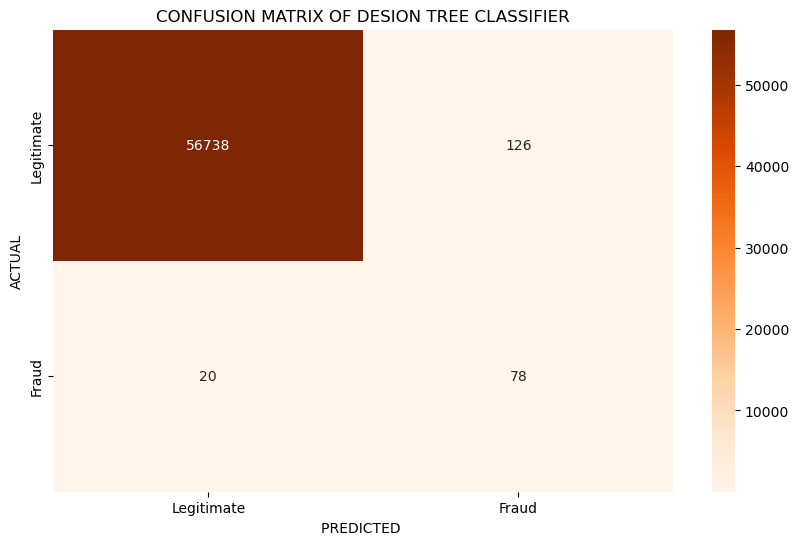

In [82]:
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Oranges',xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud'])
plt.title('CONFUSION MATRIX OF DESION TREE CLASSIFIER')
plt.xlabel('PREDICTED ')
plt.ylabel('ACTUAL')
plt.show()

In [55]:
print(classification_report(Y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.38      0.80      0.52        98

    accuracy                           1.00     56962
   macro avg       0.69      0.90      0.76     56962
weighted avg       1.00      1.00      1.00     56962



In [56]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


In [57]:
rf.fit(X_train_resampled, Y_train_resampled)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [83]:
y_pred = rf.predict(X_test_scaled)
print(y_pred)

[0 0 0 ... 0 0 0]


In [84]:
y_prob = dt.predict_proba(X_test_scaled)[:, 1]
roc_auc_score(Y_test, y_prob)

0.8968512770893388

In [85]:
print("the accuracy of rf :",accuracy_score(Y_test, y_pred))
print("the presicion of rf :",precision_score(Y_test, y_pred))
print("the recall of rf:",recall_score(Y_test, y_pred))
print("the f1_score of rf:",f1_score(Y_test, y_pred))
rf_accuracy=accuracy_score(Y_test, y_pred)
rf_precision=precision_score(Y_test, y_pred)
rf_recall=recall_score(Y_test, y_pred)
rf_f1=f1_score(Y_test, y_pred)

the accuracy of rf : 0.9994908886626171
the presicion of rf : 0.8709677419354839
the recall of rf: 0.826530612244898
the f1_score of rf: 0.8481675392670157


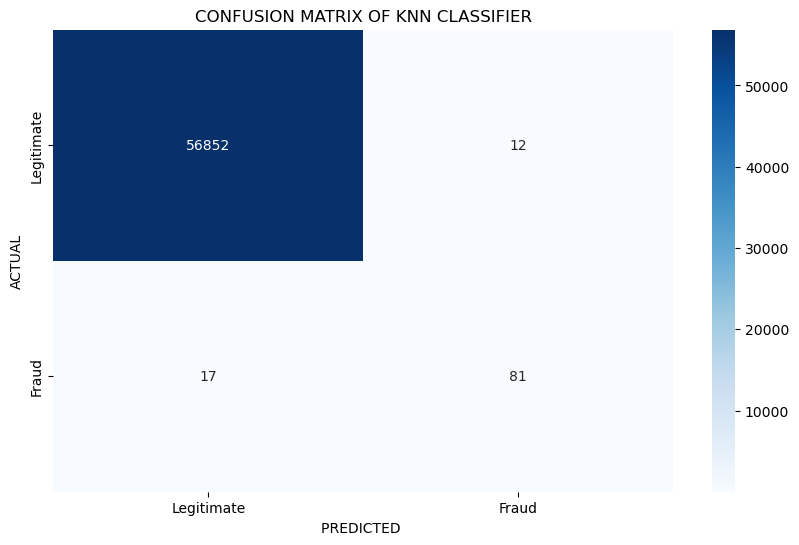

In [86]:
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(10,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['Legitimate', 'Fraud'],
    yticklabels=['Legitimate', 'Fraud'])
plt.title('CONFUSION MATRIX OF KNN CLASSIFIER')
plt.xlabel('PREDICTED ')
plt.ylabel('ACTUAL')
plt.show()

In [87]:
roc_auc_lr = roc_auc_score(
    Y_test,
    lr.predict_proba(X_test_scaled)[:, 1]
)

roc_auc_knn = roc_auc_score(
    Y_test,
    knn.predict_proba(X_test_scaled)[:, 1]
)

roc_auc_dt = roc_auc_score(
    Y_test,
    dt.predict_proba(X_test_scaled)[:, 1]
)

roc_auc_rf = roc_auc_score(
    Y_test,
    rf.predict_proba(X_test_scaled)[:, 1]
)

In [88]:
model_results = {
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest'],
    'Accuracy': [lr_accuracy, knn_accuracy, dt_accuracy, rf_accuracy],
    'Precision': [lr_precision, knn_precision, dt_precision, rf_precision],
    'Recall': [lr_recall, knn_recall, dt_recall, rf_recall],
    'F1-Score': [lr_f1, knn_f1, dt_f1, rf_f1],
    'ROC-AUC': [roc_auc_lr, roc_auc_knn, roc_auc_dt, roc_auc_rf]
}

results_df = pd.DataFrame(model_results)

results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.999491,0.870968,0.826531,0.848168,0.971327
1,KNN,0.997999,0.457447,0.877551,0.601399,0.948493
2,Decision Tree,0.997437,0.382353,0.795918,0.516556,0.896851
3,Random Forest,0.999491,0.870968,0.826531,0.848168,0.974538


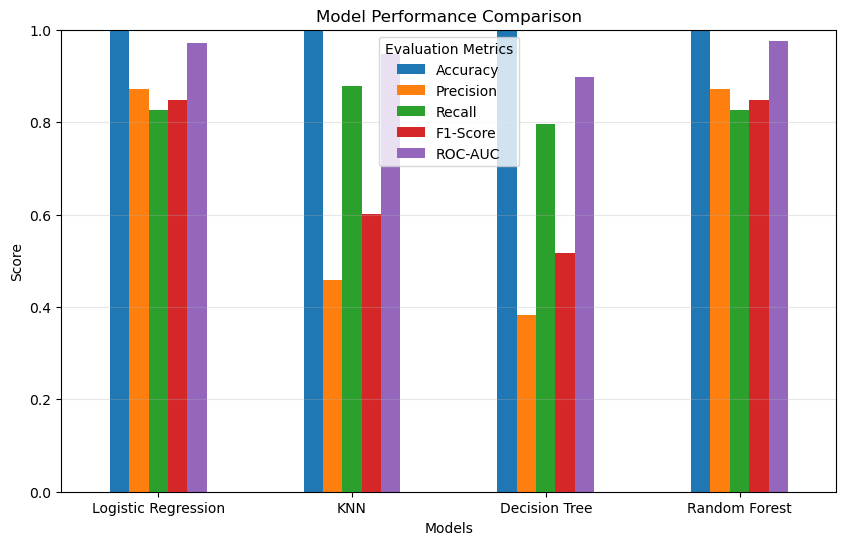

In [91]:
results_df.set_index('Model')[[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-Score',
    'ROC-AUC'
]].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(title='Evaluation Metrics')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [76]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)